<a href="https://colab.research.google.com/github/jyotinayak321/IBM-ML-Training/blob/main/IQR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




In [5]:
df = pd.read_csv('placement.csv')
print(df.head())

   cgpa  placement_exam_marks  placed
0  7.19                  26.0       1
1  7.46                  38.0       1
2  7.54                  40.0       1
3  6.42                   8.0       1
4  7.23                  17.0       0


/tmp/ipykernel_701/2031249469.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df)
/tmp/ipykernel_701/2031249469.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cgpa'])


Text(0.5, 1.0, 'CGPA Distribution')

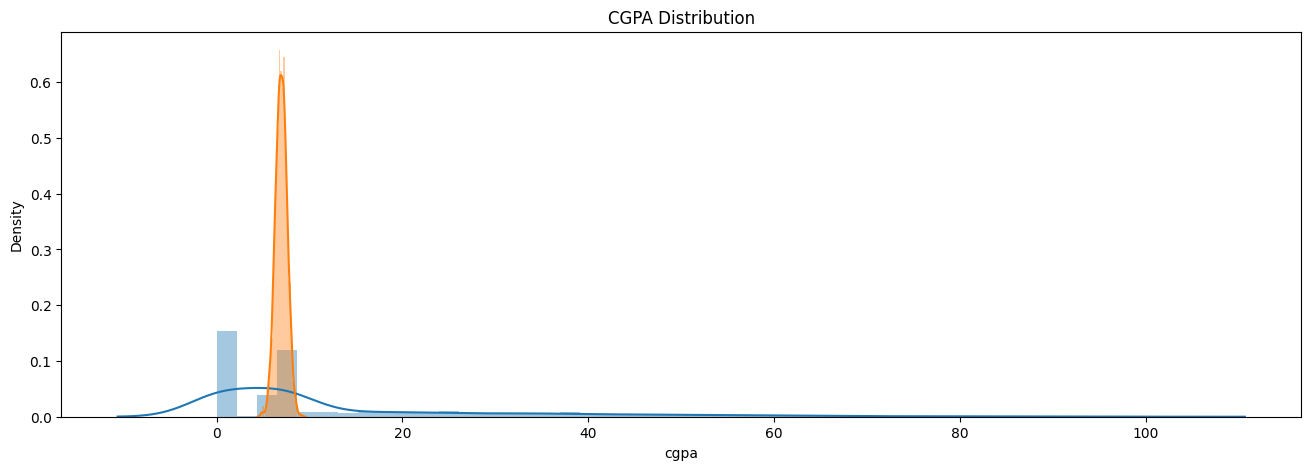

In [6]:
# visualize Distribution
plt.figure(figsize=(16,5))

#Subplot 1:CGPA Distribution
sns.distplot(df)
sns.distplot(df['cgpa'])
plt.title('CGPA Distribution')



/tmp/ipykernel_701/3565421166.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


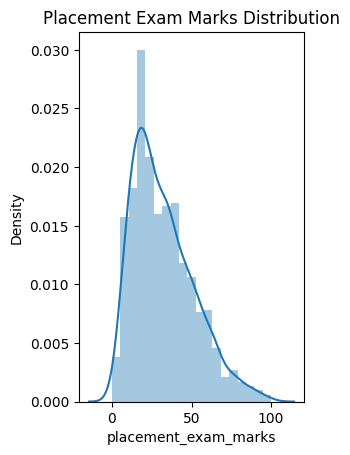

In [7]:
# Subplot 2:placement Exam Marks Distributions
plt.subplot(1,2,2)
sns.distplot(df['placement_exam_marks'])
plt.title('Placement Exam Marks Distribution')

plt.show()

observation : Placement exam shows right skewness (long tail on right)


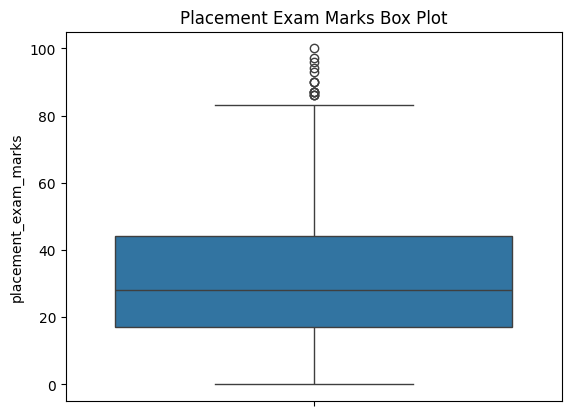

In [8]:
# Box Plot
sns.boxplot(df['placement_exam_marks'])
plt.title('Placement Exam Marks Box Plot')
plt.show()

# **observation: outliers visibles on the right side (upper end)**

In [9]:
#Calculation IQR Components


# calc Q1 (25 th percentile)
Q1 = df['placement_exam_marks'].quantile(0.25)
print(f"Q1(25 percentile):{Q1}")

# calc Q3 (75th percentiles)
Q3 = df['placement_exam_marks'].quantile(0.75)
print(f"Q2(75th percentile): {Q3}")

#Calculation IQR
IQR = Q3 - Q1
print(f"IQR: {IQR}")



#calc upppe limit and lower limit
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR
print(f"Upper Limit: {Q3 + 1.5 * IQR}")
print(f"Lower Limit: {Q1 - 1.5 * IQR}")

Q1(25 percentile):17.0
Q2(75th percentile): 44.0
IQR: 27.0
Upper Limit: 84.5
Lower Limit: -23.5


In [10]:
# find outliers above upper  limit
upper_limit_outliers =df[df['placement_exam_marks'] > upper_limit]
print(f"Number of outliers below lower limit: {len(upper_limit_outliers)}")
print(upper_limit_outliers)

Number of outliers below lower limit: 15
     cgpa  placement_exam_marks  placed
9    7.75                  94.0       1
40   6.60                  86.0       1
61   7.51                  86.0       0
134  6.33                  93.0       0
162  7.80                  90.0       0
283  7.09                  87.0       0
290  8.38                  87.0       0
311  6.97                  87.0       1
324  6.64                  90.0       0
630  6.56                  96.0       1
685  6.05                  87.0       1
730  6.14                  90.0       1
771  7.31                  86.0       1
846  6.99                  97.0       0
917  5.95                 100.0       0


In [11]:
# find outliers below lower limit
lower_outliers =df[df['placement_exam_marks'] > lower_limit]
print(f"Number of outliers below lower limit: {len(lower_outliers)}")
print(lower_outliers)

Number of outliers below lower limit: 1000
     cgpa  placement_exam_marks  placed
0    7.19                  26.0       1
1    7.46                  38.0       1
2    7.54                  40.0       1
3    6.42                   8.0       1
4    7.23                  17.0       0
..    ...                   ...     ...
995  8.87                  44.0       1
996  9.12                  65.0       1
997  4.89                  34.0       0
998  8.62                  46.0       1
999  4.90                  10.0       1

[1000 rows x 3 columns]


RESULT: 15 stuudent have marks >84.5(outlliers)

TRIMMING(REMOVING OUTLIERS)


In [17]:
#CREATE  new dataframe wiith outliers removed

new_df_trimmed = df[df['placement_exam_marks']<= upper_limit]
print(f"Original shape:{df.shape}")
print(f"New shape: {new_df_trimmed.shape}")

Original shape:(1000, 3)
New shape: (985, 3)


/tmp/ipykernel_701/2097927013.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['placement_exam_marks'])


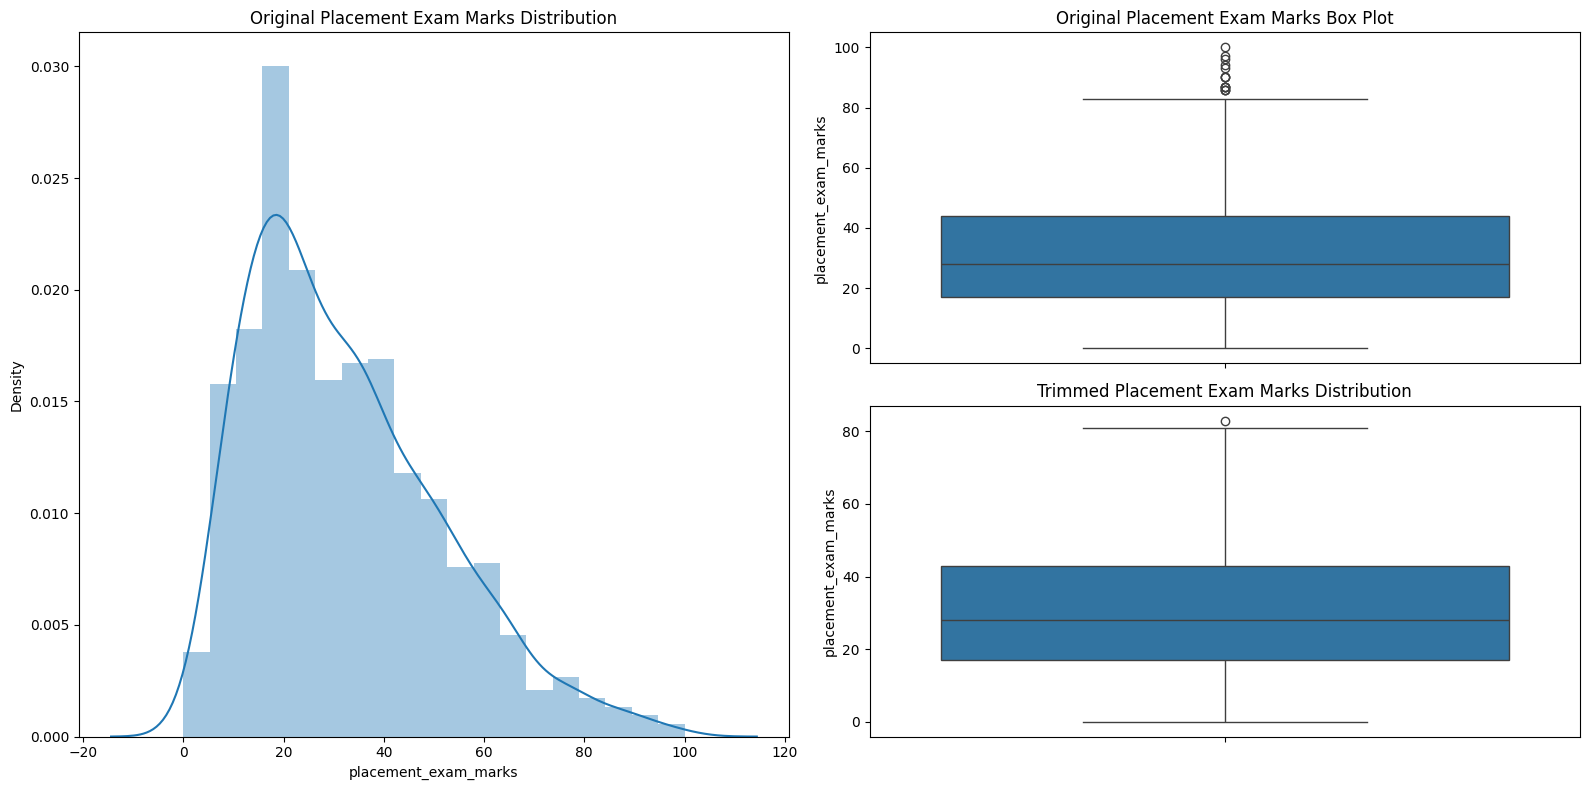

In [22]:
#visualization comparison
plt.figure(figsize=(16, 8))

#Original data -Distribution
plt.subplot(1,2,1)
sns.distplot(df['placement_exam_marks'])
plt.title('Original Placement Exam Marks Distribution')

#Original data - Box plot
plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])
plt.title('Original Placement Exam Marks Box Plot')

#Trimmed data - Distribution
plt.subplot(2,2,4)
sns.boxplot(new_df_trimmed['placement_exam_marks'])
plt.title('Trimmed Placement Exam Marks Distribution')

plt.tight_layout()
plt.show()

OBSERVATIONS:
1. Distribution becomes slightly more concentrated
2. Right tail is remove
3. Box plot shows no outliers
4. Slight increase in data density around the median



In [26]:
# METHOD 2:CAPPING (REPLACING CAPPING )


# Create a copyy of original daataframe
new_df_capped['placement_exam_marks'] = np.where(
    new_df_capped['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_capped['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_capped['placement_exam_marks']
    )
)
print(f"Original shape: {df.shape}")
print(f"New shape: {new_df_capped.shape}")

#no rows removed; outliers replace

Original shape: (1000, 3)
New shape: (1000, 3)


In [30]:
from os import replace
#Pseudocode logic:


for value in new_df_capped['placement_exam_marks']:
    if value > upper_limit:
        value = upper_limit

    elif value < lower_limit:
        value = lower_limit

    else:
        value = value